In [1]:
import pandas as pd
import sys
import pandas as pd
# adding Folder_2 to the system path
sys.path.insert(0, "/s/chromatin/m/nobackup/ahmed/DeepPlant/")
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.multiprocessing as mp
from torch.cuda import device_count
from typing import Optional, Any
from src.ddp import setup, cleanup, is_main_process
import torch.distributed as dist
from src.utils import hot_encode_sequence, create_path, save_data_to_csv
import torch
from fastprogress import progress_bar
from src.config import ExpressionConfig
from src.utils import read_json, get_device
from src.DeepPlant_expression import build_model
import numpy as np
from torch.utils.data import Dataset, DataLoader, DistributedSampler
from Bio.motifs.matrix import FrequencyPositionMatrix


In [2]:
config = ExpressionConfig(
            **read_json(
                json_path="/s/chromatin/m/nobackup/ahmed/DeepPlant/json/config_AT_expressionRC.json"
            )
        )

In [3]:
device = get_device()
model = build_model(
                args=config,
                new_model=False,
                model_path="/s/chromatin/a/nobackup/ahmed/DeepPlant/results/expression_AT/159978/model_26_03_11:12:27.pt" #'/s/chromatin/a/nobackup/ahmed/DeepPlant/results/expression_AT/803010/checkpoints/model_25_12_15:05:32.pt', #
            ).to(device)

Loading model state
Model state loaded


In [4]:
def get_gene(header):
    return header.split("_")[0]


def get_tss(header):
    return int(header.split("_")[2])
gene_df = pd.read_csv(
            "/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/expression/expression_data_TSS_centered_2500_0_RC.csv"
        )

gene_df_desc = pd.read_csv('/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/arabidopsis_expression_data_split.csv').drop(columns='Unnamed: 1')

gene_df["gene"] = list(map(get_gene, gene_df.header))
gene_df["tss"] = list(map(get_tss, gene_df.header))
gene_df_full = gene_df.merge(gene_df_desc,how='left',on=['gene','tss'])


In [5]:
gene_df_full

,header,sequence,gene,tss,split,chrom,strand
0,AT1G01010_1_3631,CATGTTTTTTAGTTGTGGCGAAAAATAAGAAATCCATACATCAACA...,AT1G01010,3631,train,1,1
1,AT1G01020_1_9130,ATCAAATCGACAAGTCATTTAACAGAATGTATTTCCCTCCCATTGC...,AT1G01020,9130,train,1,-1
2,AT1G01030_1_13714,AGGAAATTTTGGACCACACAATTTGTTGACACATCAGCAACCAAAC...,AT1G01030,13714,train,1,-1
3,AT1G01040_1_23121,CGCGTATTTTTTTATTTGAATTATTTGGTTTTTGGTTAGTTAACTA...,AT1G01040,23121,train,1,1
4,AT1G01050_1_33171,GTGGAAGGAAGTCTCCGAAGAGGTAAAACAAAAACCAATGATTCAT...,AT1G01050,33171,train,1,-1
...,...,...,...,...,...,...,...
32196,AT5G67390_5_26889367,AAATCATTCCTTATCGTAACATATAATTATGGATTAGTGAGTTGTA...,AT5G67390,26889367,test,5,-1
32197,AT5G67540_5_26946377,TTCTTTCATTCAAATAGAAGTTCAAGAACTCTGGTAAACTCTAACA...,AT5G67540,26946377,test,5,-1
32198,AT5G67550_5_26949184,GATATTATTGTTATCTCATTGAAGATTTTTTTTTCGTTTGTCAAAA...,AT5G67550,26949184,test,5,-1
32199,AT5G67560_5_26950106,GATTCCGTTAACACTTAGTTACCACATTAACGTTATAATATCACAA...,AT5G67560,26950106,test,5,1


# GEX metadata

In [6]:
import pandas as pd
gex_metadata = pd.read_csv('/s/chromatin/m/nobackup/ahmed/DeepPlant/Metadata/arabidopsis_expression_metadata_sorted.txt',sep='\t')
gex_metadata

,Sample,SampleName,Tissue,Ecotype,Genotype,Treatment,Project,TotalReads,UniqueMappedRatio,ReleaseDate
0,ERX1946687,Timepoint 10,rosette leaf,Col-0,--,Cold4C 3h*,PRJEB19974,16422598,0.9458,2018/7/4
1,ERX1946688,Timepoint 11,rosette leaf,Col-0,--,Cold4C 6h*,PRJEB19974,17555521,0.9478,2018/7/4
2,ERX1946689,Timepoint 12,rosette leaf,Col-0,--,Cold4C 9h*,PRJEB19974,18629695,0.9573,2018/7/4
3,ERX1946691,Timepoint 14,rosette leaf,Col-0,--,Cold4C 15h*,PRJEB19974,18690296,0.9536,2018/7/4
4,ERX1946693,Timepoint 16,rosette leaf,Col-0,--,Cold4C 21h*,PRJEB19974,17787214,0.9588,2018/7/4
...,...,...,...,...,...,...,...,...,...,...
3137,SRX7949154,se-2_RNA-seq_rp1,leaf,Col-0,--,--,PRJNA613247,23645521,0.7857,2020/3/19
3138,GSM4422802,t45 col 13,shoot tip,Col-0,wild type,45 minutes after 90 degree gravistimulation,PRJNA613599,24239134,0.9273,2020/3/25
3139,SRX145599,"ctr1-1 air 3-day, replicate 2",seedlings,Col-0,ctr1-1,--,SRP012592,30395294,0.8101,2012/10/19
3140,SRX145601,ein2 S645A air 3-day replicate 1,seedlings,Col-0,ein2,--,SRP012592,29082199,0.8418,2012/10/19


In [7]:
gex_metadata.loc[gex_metadata.SampleName=='WT rep1']

,Sample,SampleName,Tissue,Ecotype,Genotype,Treatment,Project,TotalReads,UniqueMappedRatio,ReleaseDate
869,GSM1279546,WT rep1,root,Col-0,wild type,untreated,PRJNA230565,14172032,0.8156,2015/7/22
978,GSM1390693,WT rep1,seedlings,Col-0,cR-grown WT,--,PRJNA248132,24919619,0.7452,2014/7/2
1136,GSM1603462,WT rep1,seedlings,Col-0,wild type,--,PRJNA274783,29411066,0.9338,2016/1/4
1254,GSM1858952,WT rep1,seedlings,Col-0,wild type,--,PRJNA293514,29082730,0.9264,2016/3/28
1438,SRX1657497,WT rep1,seedlings,Col-0,--,--,PRJNA316129,23276320,0.9332,2017/9/25
1567,GSM2159757,WT rep1,leaves,Col-0,wild type,--,PRJNA322179,14973560,0.9811,2017/5/30
1927,GSM2516569,WT rep1,rosette leaf,Col-0,wild type,--,PRJNA377549,16295013,0.9493,2018/2/16
2705,GSM3511858,WT rep1,Root,Col-0,Wild type,Protoplasted,PRJNA509920,261013034,0.7763,2019/9/18
2710,GSM3516768,WT rep1,14 day-old seedlings,Col-0,wild type,--,PRJNA510312,66494670,0.8329,2019/6/5
3130,GSM4404114,WT rep1,root,Col-0,wild type,--,PRJNA611622,9541020,0.9318,2020/3/11


In [8]:
gex_metadata.Tissue.unique()

array(['rosette leaf', 'flower buds', 'seedling', 'leaf', 'hypocotyl',
       'root', 'shoot', 'leaves', 'aerial seedling', '--', 'seedlings',
       'apical shoot meristem', 'cultured  cell', 'anther', 'stem',
       'seed', 'inflorescence', 'whole plant', 'shoot apex',
       'Inflorescence axis', 'carpels', 'flower', 'internode',
       'leaf blade', 'leaf petiole', 'leaf midrib', 'ovule', 'pedicel',
       'petal', 'pod', 'root apex', 'cotyledon', 'siliques', 'sepal',
       'stamen filament', 'stigma', 'rosette leaves', '10days seedlings',
       'growth points', 'flower bud', 'stamen', 'pollen grains',
       'whole seedling', '2-week seedlings', 'inflorescences', 'Leaves',
       'gynoecia', 'stamens',
       'Apical portions of plants (cut in hypocotyl)',
       '7-day-old root tips', 'leaves no. 5-6th darkened for 5 days',
       'uncovered leaves', 'Root', 'aerial part', 'root tip',
       'inflorescence meristems', 'meristems and young leaves',
       '1cm long root tips', '

# Functions

In [9]:
import os
from Bio import motifs
def load_motif_database(
    db_path: Optional[
        str
    ] = "/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/PFMs",  # "/s/chromatin/a/nobackup/ahmed/AT_motifs/PFMs",
):
    motifs_dict = dict()
    for pfm_file in os.listdir(db_path):
        motifs_dict[pfm_file] = motifs.read(
            open(os.path.join(db_path, pfm_file)), "pfm"
        )
    return motifs_dict


def get_motifs(motifs_dict, background):
    pssm_dict = dict()
    for tf, motif in motifs_dict.items():
        pwm = motif.counts.normalize(pseudocounts=0.5)
        pssm = pwm.log_odds(background=background)  # this converts pfm to pssm
        pssm_dict[tf] = pssm

    return pssm_dict

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ref_alt_with_logfc(ref_output, alt_output, gene, epsilon=0.5):
    """
    Visualize ref and alt outputs together with log2 fold change.

    Parameters
    ----------
    ref_output : array-like
        Reference vector (length N)
    alt_output : array-like
        Alternative/mutant vector (length N)
    epsilon : float
        Small value to avoid log(0)
    """

    ref = np.asarray(ref_output)
    alt = np.asarray(alt_output)

    assert ref.shape == alt.shape, "ref_output and alt_output must have the same shape"

    x = np.arange(len(ref))

    # log2 fold change (alt / ref)
    log2fc = 5*np.log((alt + epsilon) / (ref + epsilon))

    fig, ax1 = plt.subplots(figsize=(16, 5))

    # Plot ref and alt
    ax1.plot(x, ref, label="Ref output", alpha=0.7)
    ax1.plot(x, alt, label="Alt output", alpha=0.7)
    #ax1.plot(x, log2fc, label="logfc output", alpha=0.7)
    ax1.set_xlabel("Experiment ID")
    ax1.set_ylabel("Gene expression")
    ax1.legend(loc="upper left")

    plt.title("Ref vs Alt output with log fold change")
    plt.savefig(f"/s/chromatin/m/nobackup/ahmed/DeepPlant/results/ISM/{gene}.pdf",bbox_inches='tight', pad_inches=0.1,format = 'pdf')
    # plt.tight_layout()
    # plt.show()


In [11]:
import requests

def get_motif_name(matrix_id):
    #matrix_id = "MA1192.2"
    try:
        url = f"https://jaspar.elixir.no/api/v1/matrix/{matrix_id}"

        response = requests.get(url)
        response.raise_for_status()

        data = response.json()
        return data["name"]
    except:
        return matrix_id

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

NUCLEOTIDES = ["A", "C", "G", "T"]

def plot_variant_effects(
    ref_seq,
    mutations,          # [(nuc_index, position)]
    motif_dict,
    delta_score,
    window=30,
    tss_position=None,
    score_threshold=0.0,
    save_path=None
):
    """
    Publication-ready visualization of multiple mutations and motif gain/loss.
    """

    # -------------------------------------------------
    # 1️⃣ Build mutated sequence
    # -------------------------------------------------
    alt_seq = list(ref_seq)

    for nuc_idx, pos in mutations:
        alt_seq[pos] = NUCLEOTIDES[nuc_idx]

    alt_seq = "".join(alt_seq)

    # -------------------------------------------------
    # 2️⃣ Determine zoom region (cover all mutations)
    # -------------------------------------------------
    mutation_positions = [pos for _, pos in mutations]
    center = int(sum(mutation_positions) / len(mutation_positions))

    start = max(0, center - window)
    end = min(len(ref_seq), center + window + 1)

    ref_zoom = ref_seq[start:end]
    alt_zoom = alt_seq[start:end]

    # -------------------------------------------------
    # 3️⃣ Detect motif gain/loss in zoom window
    # -------------------------------------------------
    def scan_sequence(sequence, matrix_data, thresh):
        motif_len = len(matrix_data["A"])
        seq_len = len(sequence)
        if motif_len > seq_len:
            return -float("inf"), -1

        for pos, score in matrix_data.search(
            sequence, threshold=matrix_data.max * thresh
        ):
            return pos, score

        return -float("inf"), -1

    affected_motifs = []

    for name, matrix_data in motif_dict.items():

        sub_ref = ref_zoom
        sub_alt = alt_zoom

        pos_ref, score_ref = scan_sequence(sub_ref, matrix_data, score_threshold)
        pos_alt, score_alt = scan_sequence(sub_alt, matrix_data, score_threshold)

        is_hit_ref = score_ref >= (matrix_data.max * score_threshold)
        is_hit_alt = score_alt >= (matrix_data.max * score_threshold)

        if is_hit_ref and not is_hit_alt:
            affected_motifs.append((name, "Loss", pos_ref))

        elif not is_hit_ref and is_hit_alt:
            affected_motifs.append((name, "Gain", pos_alt))

    # -------------------------------------------------
    # 4️⃣ Plotting
    # -------------------------------------------------
    fig = plt.figure(figsize=(14, 5))
    gs = gridspec.GridSpec(4, 1, height_ratios=[1, 1, 0.8, 0.5])

    ax_ref = fig.add_subplot(gs[0])
    ax_alt = fig.add_subplot(gs[1], sharex=ax_ref)
    ax_motif = fig.add_subplot(gs[2], sharex=ax_ref)
    ax_score = fig.add_subplot(gs[3])

    # ---------------- Sequence Plot ----------------
    def plot_sequence(ax, seq, label):
        ax.set_ylim(0, 1)
        ax.set_xlim(0, len(seq))
        ax.set_yticks([])
        ax.set_ylabel(label, fontsize=11)

        for i, base in enumerate(seq):
            color = "black"
            weight = "normal"

            global_pos = start + i
            if global_pos in mutation_positions:
                color = "red"
                weight = "bold"

            ax.text(i + 0.5, 0.5, base,
                    ha="center", va="center",
                    fontsize=10,
                    family="monospace",
                    color=color,
                    fontweight=weight)

        ax.spines[['top','right','left']].set_visible(False)
        ax.tick_params(bottom=False, labelbottom=False)

    plot_sequence(ax_ref, ref_zoom, "Reference")
    plot_sequence(ax_alt, alt_zoom, "Mutant")

    # ---------------- Motif Track ----------------
    ax_motif.set_ylim(-1, 1)
    ax_motif.set_yticks([])
    ax_motif.spines[['top','right','left']].set_visible(False)

    for name, effect, pos in affected_motifs:
        if pos == -1:
            continue

        motif_len = len(motif_dict[name]["A"])
        x0 = pos
        x1 = pos + motif_len

        if effect == "Loss":
            y = 0.1
            color = "red"
            ax_motif.text((x0 + x1)/2, 0.75, name,
                          ha="center", fontsize=8)
        else:  # Gain
            y = -0.7
            color = "blue"
            ax_motif.text((x0 + x1)/2, -0.95, name,
                          ha="center", fontsize=8)

        rect = Rectangle((x0, y),
                         x1 - x0,
                         0.5,
                         facecolor=color,
                         edgecolor="black",
                         alpha=0.7)
        ax_motif.add_patch(rect)

    ax_motif.set_ylabel("Motifs\n(Loss ↑ / Gain ↓)", fontsize=10)

    # ---------------- Δ Score ----------------
    ax_score.bar([0], [delta_score[0]])
    ax_score.set_xticks([])
    ax_score.set_ylabel("Δ Score", fontsize=10)
    ax_score.spines[['top','right']].set_visible(False)

    # ---------------- Title ----------------
    if tss_position is not None:
        rel_positions = [pos - tss_position for pos in mutation_positions]
        rel_str = ", ".join([f"{p:+d}" for p in rel_positions])
        ax_ref.set_title(
            f"Mutations at {rel_str} bp relative to TSS",
            fontsize=12
        )

    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

In [13]:
def get_latest_motifs(motif_dict):
    latest_dict = {}
    
    for motif in motif_dict.keys():
        # Split 'MA1186.1.pfm' -> ['MA1186', '1', 'pfm']
        parts = motif.split('.')
        base_id = parts[0]
        version = int(parts[1])
        
        # If we haven't seen this base ID, or if this version is newer
        if base_id not in latest_dict or version > latest_dict[base_id]['version']:
            latest_dict[base_id] = {'version': version, 'full_name': motif}
            
    # Extract just the motif names
    #print(latest_dict)
    return {key['full_name']:motif_dict[key['full_name']] for key in latest_dict.values()}

In [14]:
def relative_to_genomic_position(rel_pos, tss, strand):
    """
    Convert relative position (0–2499) in 2500bp TSS-centered sequence
    to genomic coordinate.

    rel_pos: index in sequence (0-based)
    tss: integer TSS coordinate
    strand: '+' or '-'
    """

    center = 1250  # middle of 2500bp window

    rel_pos = int(rel_pos)
    tss = int(tss)
    strand = int(strand)

    # if strand == "+":
    #     # upstream is lower coordinate
    #     genomic_pos = tss - (center - rel_pos)
    # else:
    #     # reverse strand flips direction
    #     genomic_pos = tss + (center - rel_pos)
    genomic_pos = tss + (rel_pos - center)*strand
    return genomic_pos

In [15]:
def extract_chromosome(header):
    # Example header contains "Chr1"
    for token in header.split():
        if "Chr" in token:
            return token.strip()
    return None

In [16]:
def load_bed_for_tf(tf_name, metadata, bed_files_path):
    """
    Returns:
        bed_df (DataFrame) or None if not found
    """

    tf_rows = metadata.loc[metadata.Factor == tf_name]

    if len(tf_rows) == 0:
        return None

    bioproject, accession = tf_rows[['BioProject ID','Sample accession number']].values[0]

    hammock_path = f"{bed_files_path}/{bioproject}/hammock/"

    if not os.path.exists(hammock_path):
        return None

    files = os.listdir(hammock_path)

    for file in files:
        if ".target.all.bed" in file:
            if accession in file or tf_name in file:
                bed_file = pd.read_csv(
                    f"{hammock_path}/{file}",
                    delimiter="\t",
                    header=None
                )
                return bed_file

    return None

In [17]:
def check_peak_overlap(bed_df, chromosome, genomic_pos, window=0):
    
    overlaps = bed_df[
        (bed_df[0] == chromosome) &
        (bed_df[1] <= genomic_pos + window) &
        (bed_df[2] >= genomic_pos - window)
    ]

    return len(overlaps) > 0

In [18]:
def scan_variant_effects_from_dict(
    ref_seq,
    alt_seq,
    motif_dict,
    score_threshold=0.0,
):
    """
    Plots variant effects using raw dictionary PSSM data.

    Args:
        motif_dict: Dict of dicts, e.g. {'MotifName': {'A': [...], 'C': [...]}}
        score_threshold: The log-odds score threshold (e.g., 5.0).
                         Since your values go down to -11, 0 is a reasonable
                         start (better than random), but >5 is usually 'strong binding'.
    """

    # --- 1. Identify Variant ---
    variant_idx = -1
    min_len = min(len(ref_seq), len(alt_seq))
    for i in range(min_len):
        if ref_seq[i] != alt_seq[i]:
            variant_idx = i
            break

    if variant_idx == -1:
        if len(ref_seq) != len(alt_seq):
            variant_idx = min_len  # Handle indel at end
        else:
            # print("No variant found.")
            return

    # print(f"Variant found at index {variant_idx}")

    # --- 2. Helper: Manual PSSM Scoring ---
    def scan_sequence(sequence, matrix_data, thresh):
        """
        Manually scans a sequence with a weight matrix.
        Returns: (best_score, best_start_position)
        """
        # Get motif length from the 'A' list
        motif_len = len(matrix_data["A"])
        seq_len = len(sequence)

        # Safety Check: If motif is longer than sequence, we can't scan
        if motif_len > seq_len:
            return -1,-float("inf")

        # Convert dict to easier lookup format
        # keys: A, C, G, T. values: lists of weights

        best_score = -float("inf")
        best_pos = -1
        for pos, score in matrix_data.search(
            sequence, threshold=matrix_data.max * thresh
        ):
            return (pos, score)

        return best_pos, best_score

    # --- 3. Scan All Motifs ---
    affected_motifs = []

    for name, matrix_data in motif_dict.items():
        pos_ref, score_ref = scan_sequence(ref_seq, matrix_data, score_threshold)
        pos_alt, score_alt = scan_sequence(alt_seq, matrix_data, score_threshold)
        # Logic for Gain/Loss
        # print(score_alt,matrix_data)
        is_hit_ref = score_ref >= (matrix_data.max * score_threshold)
        is_hit_alt = score_alt >= (matrix_data.max * score_threshold)
        if is_hit_ref:
            is_hit_alt = score_alt >= (matrix_data.max * 0.5)
            if not is_hit_alt:
                affected_motifs.append((f"{name}({get_motif_name(name.split('.pfm')[0])})", "Loss", pos_ref))
        

        elif is_hit_alt:
            is_hit_ref = score_ref >= (matrix_data.max * 0.5)
            if not is_hit_ref:
                affected_motifs.append((f"{name}({get_motif_name(name.split('.pfm')[0])})", "Gain", pos_alt))
        # # Optional: Include "Change" if both are hits but score changes drastically
        # elif is_hit_ref and is_hit_alt and abs(score_ref - score_alt) > 3.0:
        #      effect = "Weaker" if score_alt < score_ref else "Stronger"
        #      affected_motifs.append((name, f"{effect} (Change)", matrix_data, pos_alt))
    #print(affected_motifs)
    return affected_motifs

In [19]:
def analyze_mutations_with_chip(
    gene,
    sum_lfc,
    ref_sequence,
    nuclt,
    gene_df_full,
    motif_dict,
    metadata,
    bed_files_path,
    mutation_threshold=0.7,
    score_threshold=0.7,
    pad=15
):

    results = []
    sum_lfc = sum_lfc-sum_lfc.mean(0)

    # -------------------
    # Gene information
    # -------------------
    row = gene_df_full.loc[gene_df_full.gene == gene].iloc[0]

    strand = str(row.strand)
    tss = int(row.tss)
    chromosome = f"Chr{str(row.chrom)}"

    # -------------------
    # Identify strong mutations
    # -------------------
    rows, cols = np.where(sum_lfc < mutation_threshold * sum_lfc.min())
    indices = list(zip(rows, cols))

    for nuc_index, pos in indices:
        

        mutation = nuclt[nuc_index]


        if ref_sequence[pos] == mutation:
            continue

        # -------------------
        # Local sequence window
        # -------------------
        ref_local = ref_sequence[pos-pad:pos+pad]
        alt_local = (
            ref_sequence[pos-pad:pos] +
            mutation +
            ref_sequence[pos+1:pos+pad]
        )

        # -------------------
        # Scan motif effects
        # -------------------
        affected = scan_variant_effects_from_dict(
            ref_local,
            alt_local,
            motif_dict,
            score_threshold
        )

        if not affected:
            continue
        # -------------------
        # Convert to genomic coordinate
        # -------------------
        genomic_pos = relative_to_genomic_position(
            rel_pos=pos,
            tss=tss,
            strand=strand
        )
        # -------------------
        # Check each motif
        # -------------------
        for motif_name, effect, motif_rel_pos in affected:

            tf_name = motif_name.split("(")[1].replace(")", "")
            bed_df = load_bed_for_tf(tf_name, metadata, bed_files_path)
            

            if bed_df is None:
                peak_status = "No bed file found"
            else:
                peak_status = check_peak_overlap(
                    bed_df,
                    chromosome,
                    genomic_pos
                )

            results.append({
                "gene": gene,
                "chromosome": chromosome,
                "relative_position": pos,
                "genomic_position": genomic_pos,
                "strand": strand,
                "ref": ref_sequence[pos],
                "alt": mutation,
                "motif": tf_name,
                "effect": effect,
                "chip_peak_overlap": peak_status
            })

    return pd.DataFrame(results)

In [20]:
def nuclt_dict(sequences):
    back_freq = {"A": 0, "C": 0, "G": 0, "T": 0}
    for sequence in sequences:
        for nuclt in back_freq.keys():
            back_freq[nuclt] += sequence.count(nuclt)
    back_freq = {key: back_freq[key] / sum(back_freq.values()) for key in back_freq}
    return back_freq

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import matplotlib.font_manager as fm


def draw_letter(ax, letter, x, height, color):
    """
    Draw a nucleotide letter at position x.
    Positive height → upright.
    Negative height → flipped vertically (head-down).
    """

    if height == 0:
        return

    text = TextPath(
        (0, 0), letter, size=1,
        prop=fm.FontProperties(family="DejaVu Sans", weight="bold")
    )

    if height > 0:
        transform = Affine2D().scale(1, height).translate(x, 0)
    else:
        transform = ( Affine2D().scale(1, height).translate(x, 0) )

    patch = PathPatch(
        text,
        lw=0,
        fc=color,
        transform=transform + ax.transData
    )

    ax.add_patch(patch)

In [22]:
metadata = pd.read_csv('/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/metadata/AT_Metadata.csv')
bed_files_path = '/s/chromatin/b/nobackup/deepplant/Data/arabidopsis_thaliana/Chiphub_bedfile'
motifs_dict = load_motif_database()
motifs_dict = get_latest_motifs(motifs_dict)
back_freq = nuclt_dict(gene_df_full.sequence.values.tolist()) #{"A": 0.25, "C": 0.25, "G": 0.25, "T": 0.25}
pssm_dict_jaspar = get_motifs(motifs_dict, back_freq)

# AT5G52310 gene (RAD29A) / General stress

In [23]:
gene = "AT5G52310" 
header = gene_df_full.loc[gene_df_full.gene==gene].header.values[0].__str__()
sequence = gene_df_full.loc[gene_df_full.gene==gene].sequence.values[0].__str__()
strand = gene_df_full.loc[gene_df_full.gene==gene].strand.values[0].__str__()
tss = gene_df_full.loc[gene_df_full.gene==gene].tss.values[0].__str__()
chrom = gene_df_full.loc[gene_df_full.gene==gene].chrom.values[0].__str__()
gene_df_full.loc[gene_df_full.gene==gene]

,header,sequence,gene,tss,split,chrom,strand
31476,AT5G52310_5_21240717,ATGTATTTTATCTTTGTGTGAAAAAGAGATTGGGTTAATAAAATAT...,AT5G52310,21240717,test,5,1


In [24]:
gene_output = np.load(f"/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/expression/{gene_df_full.loc[gene_df_full.gene==gene].header.values[0]}.npy")
gene_output.argmax(),gex_metadata.iloc[gene_output.argmax()],np.argsort(gene_output)[-15:]

(380,
 Sample                     SRX5371774
 SampleName           Hypocotyl_cold27
 Tissue                      hypocotyl
 Ecotype                         Col-0
 Genotype                           --
 Treatment                          --
 Project                   PRJNA411947
 TotalReads                   21497670
 UniqueMappedRatio              0.8477
 ReleaseDate                 2019/2/14
 Name: 380, dtype: object,
 array([ 129,  599, 1560,  600, 1562, 1612,  381, 2402, 1614,   99,  128,
        1557, 1558,   75,  380]))

In [25]:
nuclt = ["A", "C", "G", "T"]
sum_lfc = torch.zeros(4, 2500, 3142).to(device)
ref_allele = sequence
eps = 1.0
ref_input = torch.from_numpy(hot_encode_sequence(sequence=ref_allele, length_after_padding=2500)).unsqueeze(0).to(device)
with torch.no_grad():
    model.eval()
    ref_labels = model(input=ref_input)
    for idx in progress_bar(range(len(ref_allele))):
        for j, nucl in enumerate(nuclt):
            if ref_allele[idx] != nucl:
                mut_allele = ref_allele[:idx] + nucl + ref_allele[idx + 1 :]
                mut_input = (
                    torch.tensor(
                        hot_encode_sequence(mut_allele), dtype=torch.float
                    )
                    .unsqueeze(0)
                    .to(device)
                )
                mut_label = model(input=mut_input)
                sum_lfc[j, idx] = (torch.log(mut_label + eps) - torch.log(ref_labels + eps))
sum_lfc = sum_lfc.cpu().numpy()

# Cold-stress

### Cold 1-hour

In [46]:
exp_id = 279
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

Sample                SRX1881751
SampleName           Cold 1 hour
Tissue                    leaves
Ecotype                    Col-0
Genotype                      --
Treatment                   cold
Project              PRJNA324514
TotalReads              39782302
UniqueMappedRatio         0.9034
ReleaseDate            2016/8/26
Name: 279, dtype: object
gene expression is  67.696846
most important positions are  [1159 1160 1161 1162 1163 1215 1216 1217 1218 1219 1220 1221 1256 1257
 1264 1266 1268 1269 1281 1296 1300 1311 1318 1319 1320 1321 1322 1324
 1849]


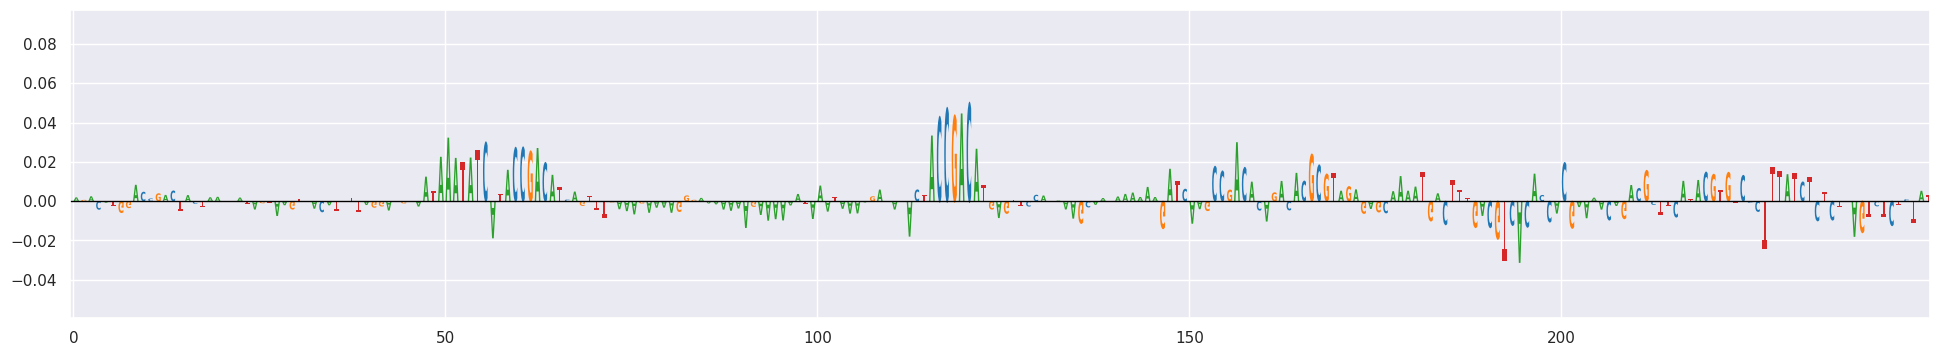

In [53]:
n0 = 1100
n1 = 1350
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Cold 3-hours

In [47]:
exp_id = 282
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

Sample                 SRX1881753
SampleName           Cold 3 hours
Tissue                     leaves
Ecotype                     Col-0
Genotype                       --
Treatment                    cold
Project               PRJNA324514
TotalReads               27297258
UniqueMappedRatio          0.9087
ReleaseDate             2016/8/26
Name: 282, dtype: object
gene expression is  198.02907
most important positions are  [1150 1154 1155 1159 1160 1162 1215 1216 1217 1218 1219 1220 1221 1253
 1254 1256 1257 1300 1318 1319 1320 1321 1322 1324 1509 1806 1849]


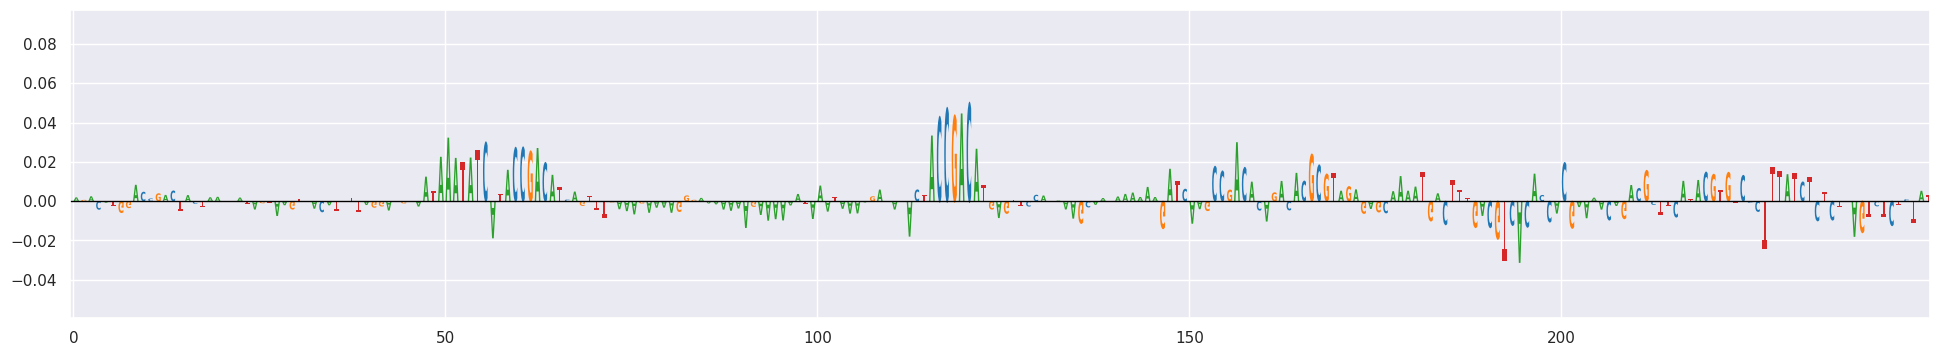

In [55]:
n0 = 1100
n1 = 1350
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Cold 6-hours

In [49]:
exp_id = 283
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                 SRX1881761
SampleName           Cold 6 hours
Tissue                     leaves
Ecotype                     Col-0
Genotype                       --
Treatment                    cold
Project               PRJNA324514
TotalReads               25601261
UniqueMappedRatio          0.9113
ReleaseDate             2016/8/26
Name: 283, dtype: object
gene expression is  230.1098
most important positions are  [1150 1154 1155 1159 1160 1161 1162 1215 1216 1217 1218 1219 1220 1221
 1256]


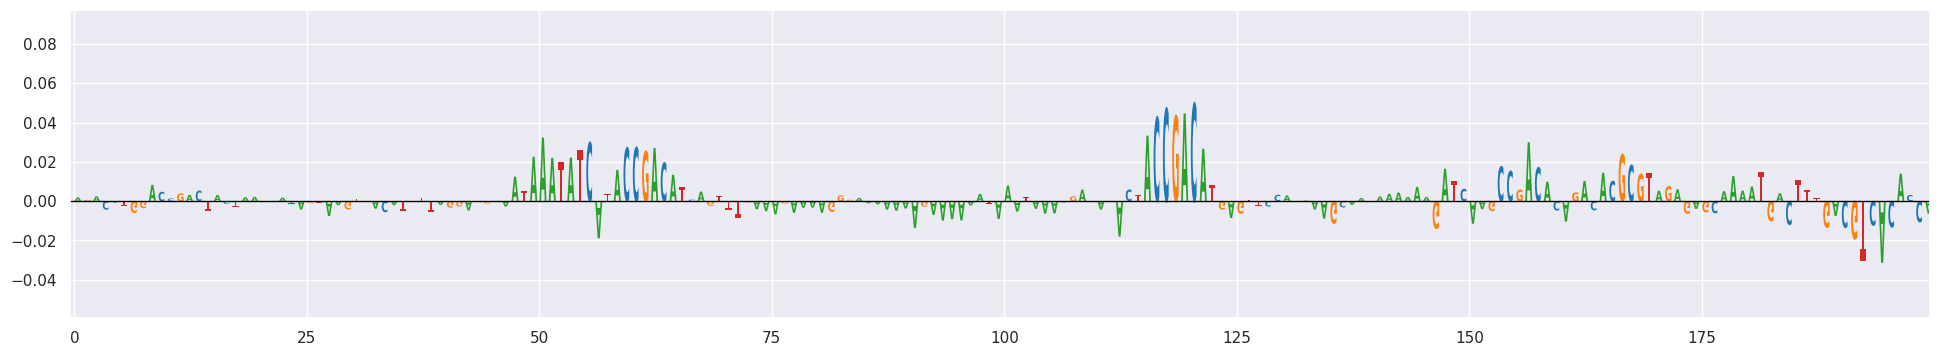

In [51]:
n0 = 1100
n1 = 1300
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Cold 12-hours

In [56]:
exp_id = 280
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                  SRX1881839
SampleName           Cold 12 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     cold
Project                PRJNA324514
TotalReads                36203588
UniqueMappedRatio           0.9146
ReleaseDate              2016/8/26
Name: 280, dtype: object
gene expression is  200.91248
most important positions are  [1149 1150 1151 1153 1154 1155 1215 1216 1217 1218 1219 1220]


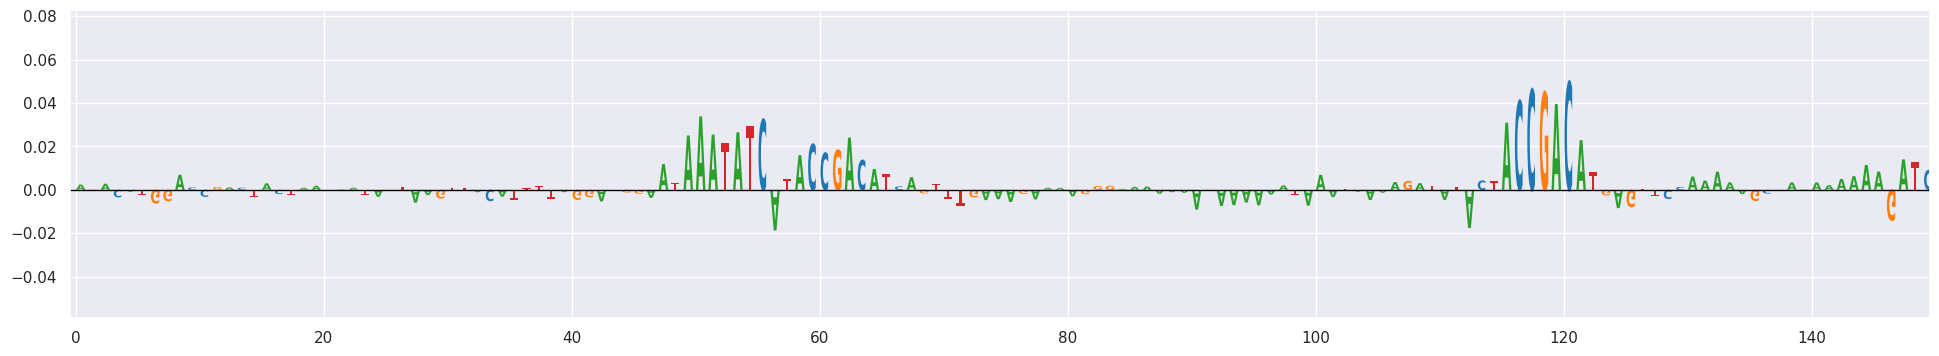

In [57]:
n0 = 1100
n1 = 1250
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Cold 24-hours

In [62]:
exp_id = 281
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                  SRX1881841
SampleName           Cold 24 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     cold
Project                PRJNA324514
TotalReads                43221967
UniqueMappedRatio           0.8688
ReleaseDate              2016/8/26
Name: 281, dtype: object
gene expression is  157.03745
most important positions are  [1150 1159 1215 1216 1217 1218 1219 1220 1318 1319 1320 1322]


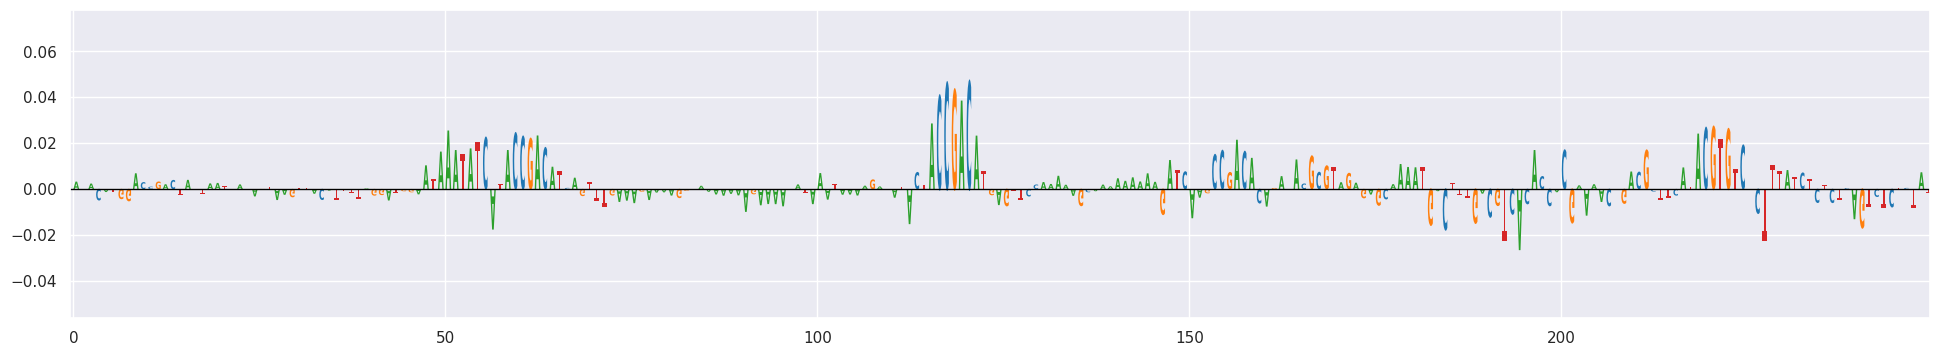

In [63]:
n0 = 1100
n1 = 1350
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# Heat

### Heat 1-hour

In [65]:
exp_id = 284
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

Sample                SRX1881868
SampleName           Heat 1 hour
Tissue                    leaves
Ecotype                    Col-0
Genotype                      --
Treatment                   heat
Project              PRJNA324514
TotalReads              13822746
UniqueMappedRatio         0.8176
ReleaseDate            2016/8/26
Name: 284, dtype: object
gene expression is  44.163143
most important positions are  [1159 1160 1161 1162 1163 1215 1216 1217 1218 1219 1220 1221 1257 1266
 1300 1318 1319 1320 1321 1322 1324 1849]


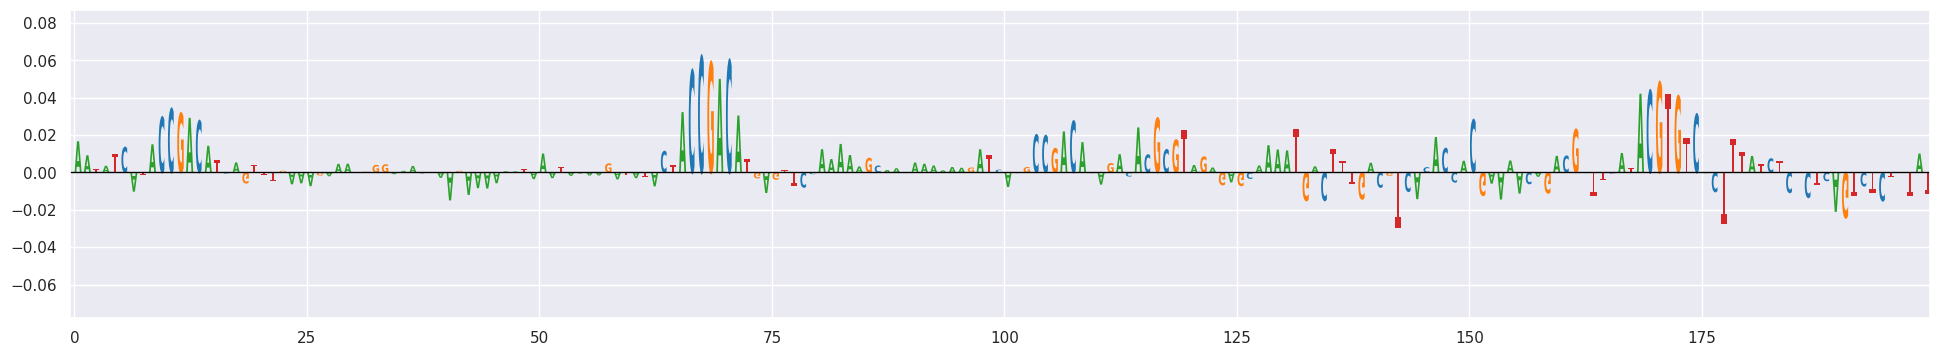

In [66]:
n0 = 1150
n1 = 1350
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Heat 12-hours

In [68]:
exp_id = 285
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

Sample                  SRX1881889
SampleName           Heat 12 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     heat
Project                PRJNA324514
TotalReads                16739193
UniqueMappedRatio           0.8006
ReleaseDate              2016/8/26
Name: 285, dtype: object
gene expression is  59.98946
most important positions are  [1150 1153 1154 1155 1159 1160 1161 1162 1163 1216 1217 1218 1220 1266
 1285 1300 1311 1318 1319 1320 1321 1322 1324 1464]


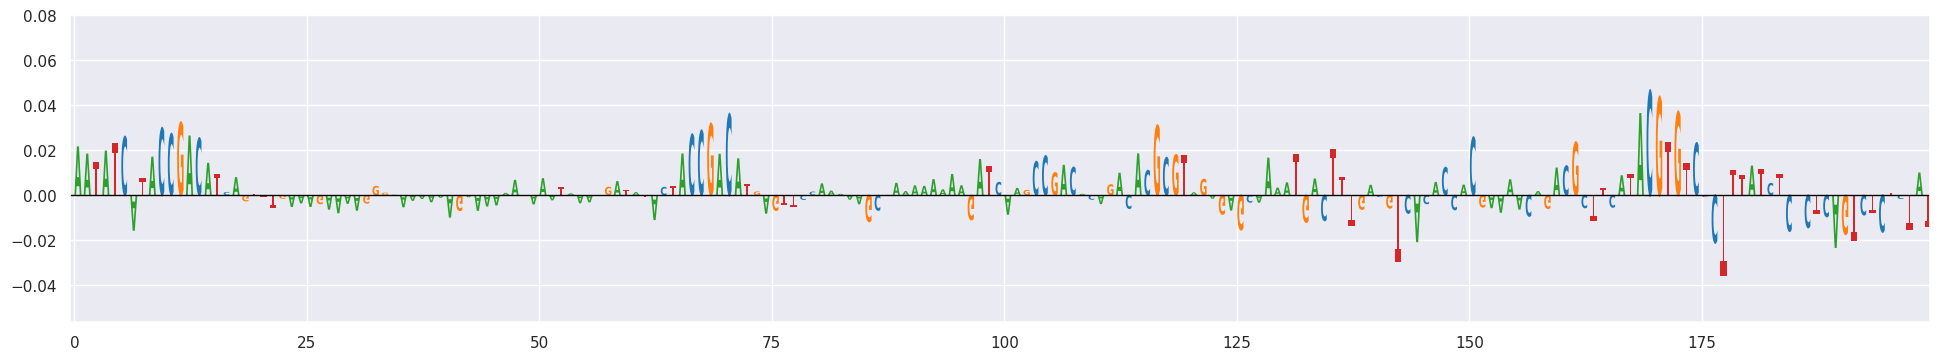

In [69]:
n0 = 1150
n1 = 1350
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Heat 24-hours

In [70]:
exp_id = 286
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

Sample                  SRX1881908
SampleName           Heat 24 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     heat
Project                PRJNA324514
TotalReads                16442117
UniqueMappedRatio           0.8158
ReleaseDate              2016/8/26
Name: 286, dtype: object
gene expression is  82.115814
most important positions are  [1154 1155 1159 1160 1161 1162 1163 1215 1216 1217 1218 1219 1220 1264
 1265 1266 1267 1268 1269 1285 1300 1311 1318 1319 1320 1321 1322]


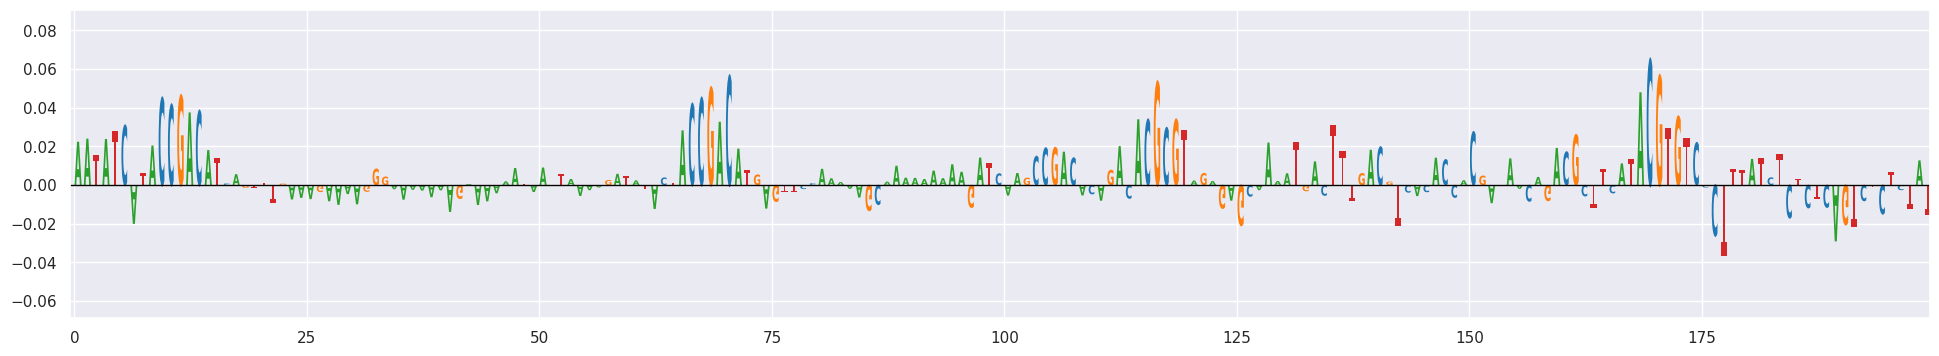

In [71]:
n0 = 1150
n1 = 1350
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# Wounding

### Wounding 1-hour

In [73]:
exp_id = 287
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

Sample                    SRX1882433
SampleName           Wounding 1 hour
Tissue                        leaves
Ecotype                        Col-0
Genotype                          --
Treatment                   wounding
Project                  PRJNA324514
TotalReads                  16104177
UniqueMappedRatio             0.8435
ReleaseDate                2016/8/26
Name: 287, dtype: object
gene expression is  202.35883
most important positions are  [1159 1160 1161 1162 1163 1215 1216 1217 1218 1219 1220 1221 1256 1264
 1266 1318 1319 1320 1321 1322]


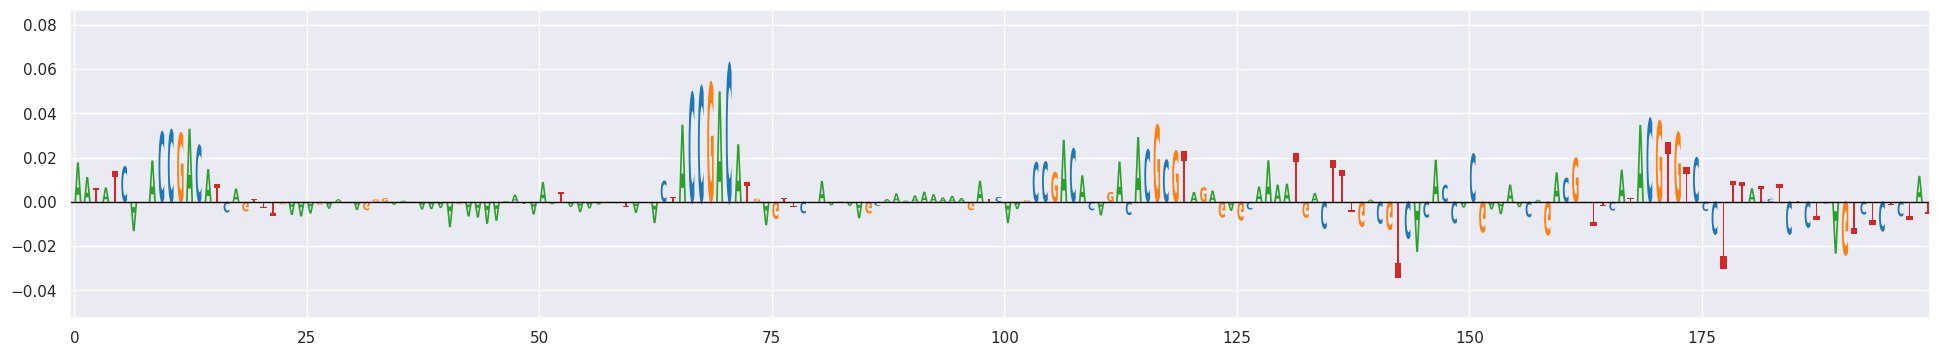

In [75]:
n0 = 1150
n1 = 1350
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Wounding 12-hours 

In [78]:
exp_id = 288
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

Sample                      SRX1882503
SampleName           Wounding 12 hours
Tissue                          leaves
Ecotype                          Col-0
Genotype                            --
Treatment                     wounding
Project                    PRJNA324514
TotalReads                    19322440
UniqueMappedRatio               0.8328
ReleaseDate                  2016/8/26
Name: 288, dtype: object
gene expression is  104.7405
most important positions are  [1149 1150 1151 1153 1154 1155 1159 1160 1161 1162 1163 1215 1216 1217
 1218 1219 1220 1256 1257 1264 1265 1266 1267 1268 1269 1296 1300 1328
 1329 1509 1806 1849 1873]


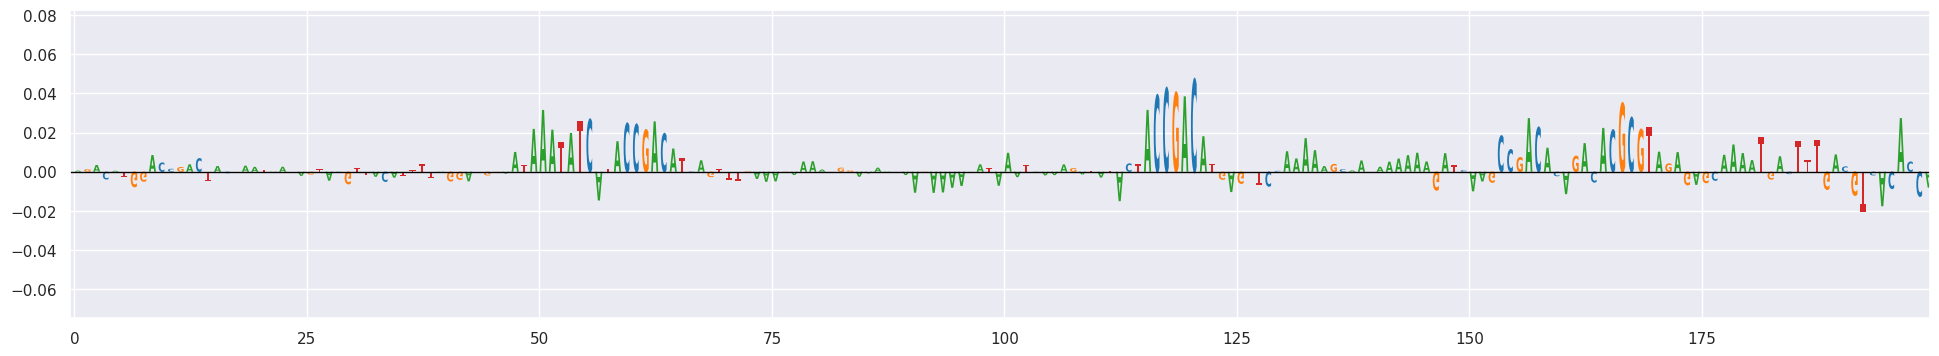

In [77]:
n0 = 1100
n1 = 1300
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Wounding 24-hours

In [82]:
exp_id = 289
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

Sample                      SRX1882526
SampleName           Wounding 24 hours
Tissue                          leaves
Ecotype                          Col-0
Genotype                            --
Treatment                     wounding
Project                    PRJNA324514
TotalReads                    17097515
UniqueMappedRatio               0.8442
ReleaseDate                  2016/8/26
Name: 289, dtype: object
gene expression is  26.526167
most important positions are  [1159 1160 1161 1162 1163 1215 1216 1217 1218 1219 1220 1221 1256 1257
 1264 1266 1269 1281 1296 1300 1311 1318 1319 1320 1321 1322 1324 1328
 1509 1806 1813 1849]


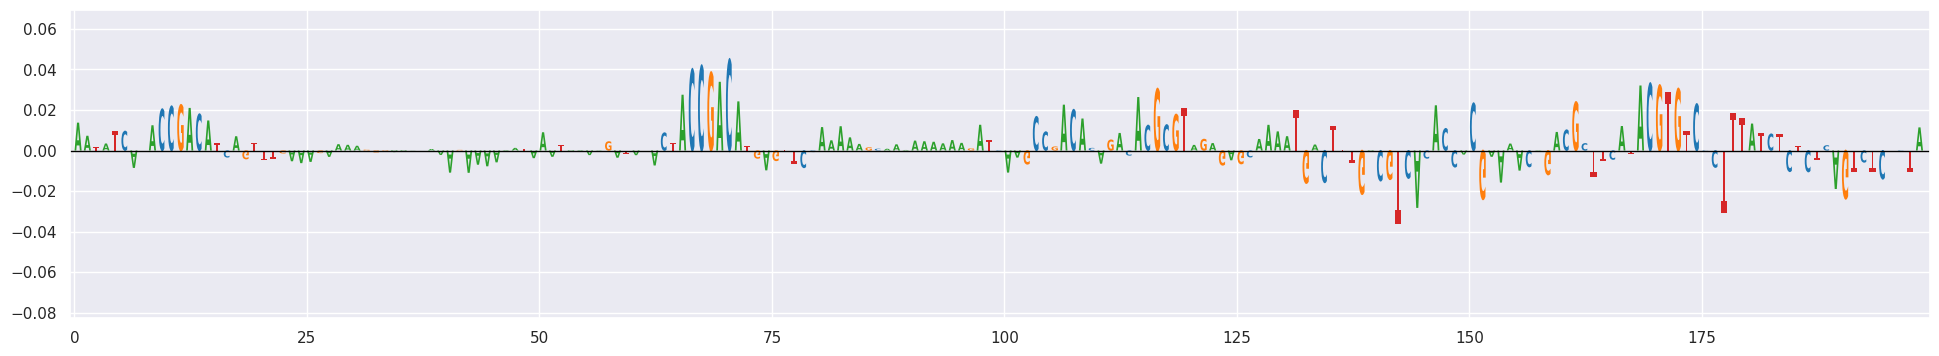

In [83]:
n0 = 1150
n1 = 1350
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# Drought

### Early Drought

In [149]:
exp_id = 1879
nuc_to_index = {'A':0,'C':1,'G':2,'T':3}
# Convert sequence to row indices
rows = np.array([nuc_to_index[n] for n in ref_allele])

# Column indices
cols = np.arange(len(sequence))
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values =(sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

Sample                    GSM2466002
SampleName           WT drought rep1
Tissue                        leaves
Ecotype                        Col-0
Genotype                   wild type
Treatment                    drought
Project                  PRJNA362994
TotalReads                   7976843
UniqueMappedRatio             0.8887
ReleaseDate                2017/6/13
Name: 1879, dtype: object
gene expression is  101.07486
most important positions are  [1149 1150 1151 1152 1153 1154 1155 1159 1160 1161 1162 1215 1216 1217
 1218 1219 1220 1221 1253 1256 1266 1267 1268 1269 1300 1310 1311 1324
 1328 1329 1330 1331 1332 1404 1405 1433 1452 1464 1465 1474 1476 1497
 1500 1506 1509 1510 1512 1515 1590 1597 1629 1638 1645 1725 1750 1757
 1762 1777 1778 1796 1797 1806 1812 1813 1814 1822 1823 1824 1831 1849
 1861 1873 1898 2331]


In [128]:
hot_encode_sequence(ref_allele).shape

(4, 2500)

In [147]:
nuc_to_index = {'A':0,'C':1,'G':2,'T':3}
# Convert sequence to row indices
rows = np.array([nuc_to_index[n] for n in ref_allele])

# Column indices
cols = np.arange(len(sequence))

# Extract values
vector = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
vector.shape

(2500,)

In [145]:
((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).shape

(4, 2500)

In [144]:
(((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele))[[nuc_to_index[i] for i in ref_allele],:]).shape

(2500, 2500)

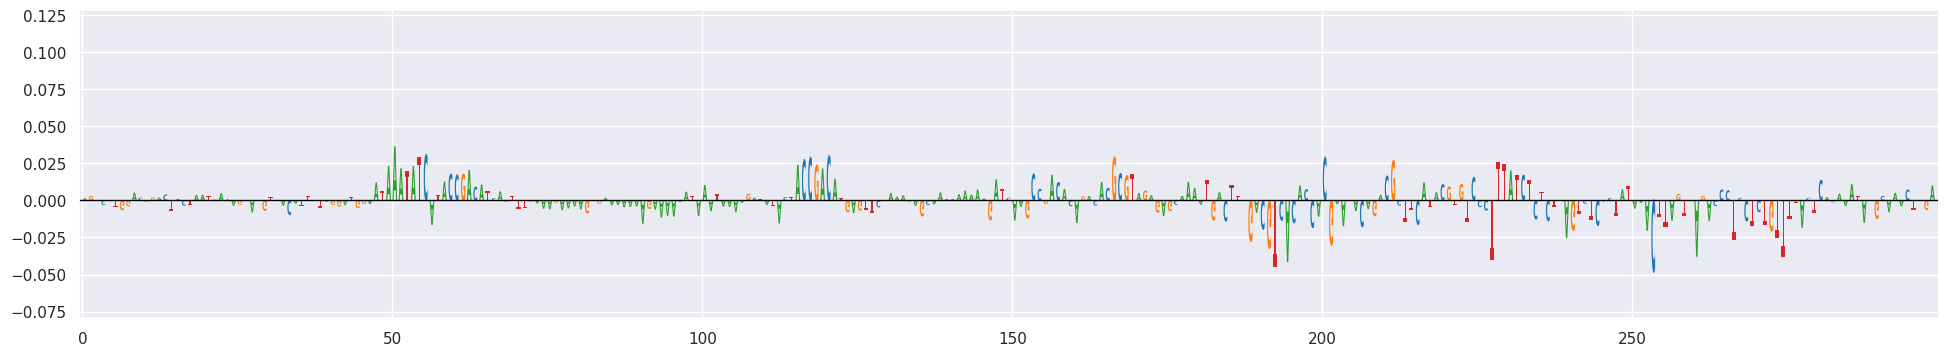

In [112]:
n0 = 1100
n1 = 1400
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

In [121]:
np.max(exp_sum_lfc)

0.12662104

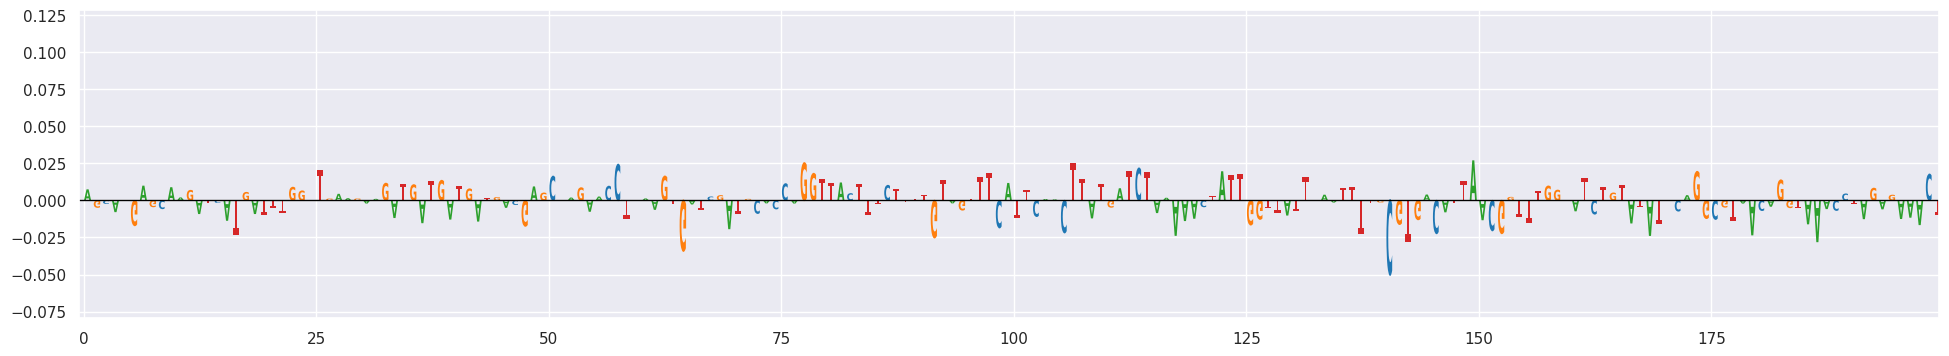

In [102]:
n0 = 1700
n1 = 1900
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

In [85]:
np.argsort(gene_output)[-100:]

array([2489, 1877,  354, 1947,  237, 1858, 2816, 1780, 1748, 1477,  839,
       3134,  384, 2493, 1708, 1427, 2613, 1422,  273, 3038, 2039, 1419,
       2734, 1404, 1598, 1743, 1474, 1714,  356, 1734, 1095, 1851, 2960,
       2385,  357, 1724,  386, 2846,  290, 1428,  197, 2733, 1406, 1429,
        252, 2488, 1559, 2836,  111, 2030, 1097,  472,  282, 2729,  355,
       2485,  280, 3069, 1700,  287, 1405, 2484, 2963, 2728, 2487, 2483,
       2997, 2628,  283,  375,  376,  598, 2492, 1615, 2495,  383, 1611,
       2496, 2494, 1613,  578, 2490,  577, 1675,  579,  129,  599, 1560,
        600, 1562, 1612,  381, 2402, 1614,   99,  128, 1557, 1558,   75,
        380])

In [94]:
gex_metadata.iloc[1614]

Sample                                                      SRX1994728
SampleName                                                     PAZ-004
Tissue                                                  Rosette leaves
Ecotype                                                          Col-0
Genotype                                                     wild type
Treatment            Drought stress conditions (withholding water H...
Project                                                    PRJNA336152
TotalReads                                                    11843011
UniqueMappedRatio                                               0.9035
ReleaseDate                                                 2019/12/31
Name: 1614, dtype: object

In [ ]:
exp_id = 289
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.4*ISM_values.max())[0])

# Normal condition

In [94]:
exp_id = 1927#1567#3130#750#1927
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                 GSM2516569
SampleName                WT rep1
Tissue               rosette leaf
Ecotype                     Col-0
Genotype                wild type
Treatment                      --
Project               PRJNA377549
TotalReads               16295013
UniqueMappedRatio          0.9493
ReleaseDate             2018/2/16
Name: 1927, dtype: object
gene expression is  4.935356
most important positions are  [1145 1146 1147 1148 1149 1196 1198 1363 1364 1367]


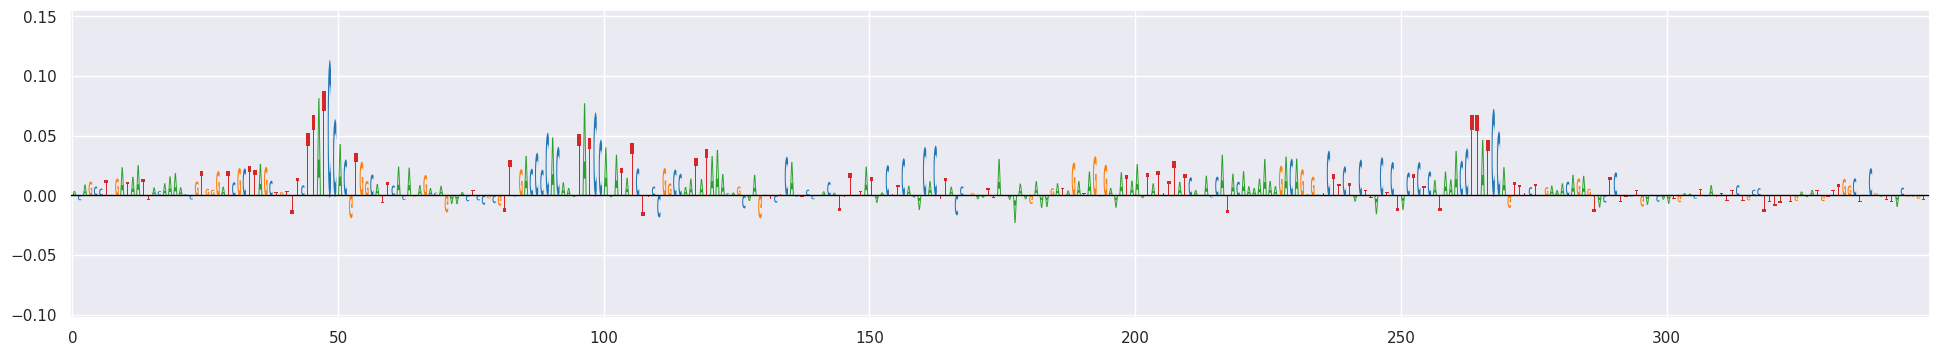

In [95]:
n0 = 1100
n1 = 1450
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# General mutations

In [92]:
general_sum_lfc = sum_lfc.mean(axis=2)
ISM_values = ((general_sum_lfc-general_sum_lfc.mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
np.where(ISM_values>0.5*ISM_values.max())

(array([1145, 1146, 1147, 1148, 1149, 1150, 1195, 1196, 1198, 1363, 1367]),)

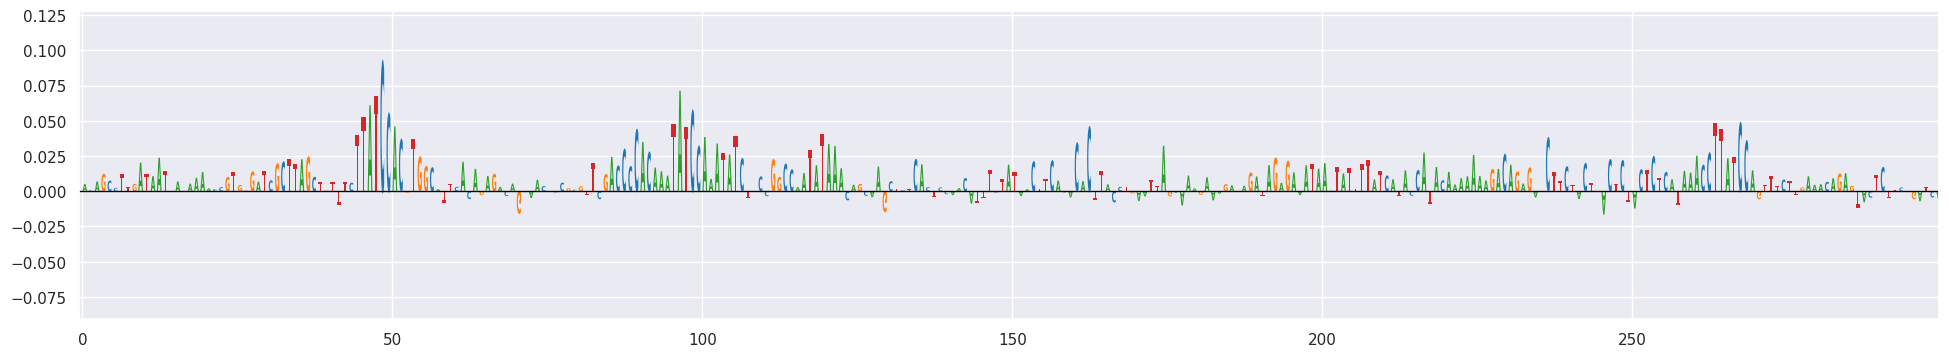

In [93]:
n0 = 1100
n1 = 1400
exp_sum_lfc = general_sum_lfc-general_sum_lfc.mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# General important mutations

In [76]:
general_sum_lfc = sum_lfc.mean(axis=2)

In [ ]:
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=general_sum_lfc,
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df_full,
    motif_dict=pssm_dict_jaspar,
    metadata=metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=0.5,
    score_threshold=0.8,
    pad=15
)
results_df.to_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}.csv",index=False)
results_df.head()

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
0,AT4G25470,Chr4,1149,13016336,-1,C,A,bHLH74,Loss,False
1,AT4G25470,Chr4,1149,13016336,-1,C,A,NID1,Loss,No bed file found
2,AT4G25470,Chr4,1149,13016336,-1,C,A,DOF5.3,Gain,No bed file found
3,AT4G25470,Chr4,1149,13016336,-1,C,A,BZIP28,Loss,No bed file found
4,AT4G25470,Chr4,1149,13016336,-1,C,A,MYC3,Loss,False


In [118]:
results_df.chip_peak_overlap.value_counts()

chip_peak_overlap
No bed file found    137
False                 50
True                  46
Name: count, dtype: int64

In [121]:
results_df.loc[results_df.chip_peak_overlap==True]

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
5,AT4G25470,Chr4,1149,13016336,-1,C,A,AT5G04760,Loss,True
7,AT4G25470,Chr4,1149,13016336,-1,C,A,PIF1,Loss,True
10,AT4G25470,Chr4,1149,13016336,-1,C,A,ABF4,Loss,True
12,AT4G25470,Chr4,1149,13016336,-1,C,A,PIF3,Loss,True
15,AT4G25470,Chr4,1149,13016336,-1,C,A,BIM2,Loss,True
19,AT4G25470,Chr4,1149,13016336,-1,C,A,GBF2,Loss,True
23,AT4G25470,Chr4,1149,13016336,-1,C,A,PIF4,Loss,True
26,AT4G25470,Chr4,1149,13016336,-1,C,A,ABF1,Loss,True
28,AT4G25470,Chr4,1149,13016336,-1,C,A,PIF5,Loss,True
35,AT4G25470,Chr4,1149,13016336,-1,C,A,ABI5,Loss,True


In [122]:
results_df.loc[results_df.effect=='Loss'].motif.unique()

array(['bHLH74', 'NID1', 'BZIP28', 'MYC3', 'AT5G04760', 'BZIP16', 'PIF1',
       'DPBF3', 'BHLH72', 'ABF4', 'PIF3', 'HBI1', 'BZIP63', 'BIM2',
       'DIV1', 'ILR3', 'GBF2', 'BPE', 'ABF2', 'KUA1', 'PIF4', 'BZIP68',
       'ABF1', 'SPT', 'PIF5', 'BEE2', 'URI', 'NF-YB9', 'UN0823.1', 'BIM3',
       'ABI5', 'AT4G09450', 'ZAT7', 'AT5G04390', 'AZF2', 'YAB4',
       'AT3G10580', 'AT1G74840', 'AT5G56840', 'AT1G19000', 'STKL2',
       'AT2G38090', 'MA1681.2', 'AT5G05790', 'AT5G61620', 'MBD2', 'TREE1',
       'AT2G28920', 'RVE7L', 'RVE8', 'RVE1', 'LHY', 'CCA1', 'KAN1', 'CRC',
       'TRP5'], dtype=object)

In [123]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import matplotlib.font_manager as fm


def draw_letter_for_comp(ax, letter, x, height, color):
    """
    Draw a nucleotide letter at position x.
    Positive height → upright.
    Negative height → flipped vertically (head-down).
    """

    if height == 0:
        return

    text = TextPath(
        (0, 0), letter, size=1,
        prop=fm.FontProperties(family="DejaVu Sans", weight="bold")
    )

    if height > 0:
        transform = (
            Affine2D()
            .scale(1, height)
            .translate(x, 0)
        )
    else:
        transform = (
            Affine2D()
            .scale(1, height)   # negative scale flips vertically
            .translate(x, 0)
        )

    patch = PathPatch(
        text,
        lw=0,
        fc=color,
        transform=transform + ax.transData
    )

    ax.add_patch(patch)

In [124]:
def plot_ref_alt_ism(
    gene,
    chrom,
    sum_lfc,
    ref_sequence,
    results_df,
    window_padding=20
):

    letters = ['A', 'C', 'G', 'T']
    letter_to_index = {l: i for i, l in enumerate(letters)}

    colors = {
        'A': '#2ca02c',
        'C': '#1f77b4',
        'G': '#ff7f0e',
        'T': '#d62728'
    }

    mut_positions = results_df.relative_position.values
    start = max(0, min(mut_positions) - window_padding)
    end = min(2500, max(mut_positions) + window_padding)
    region = range(start, end)

    mutation_dict = {}
    for _, row in results_df.iterrows():
        pos = int(row.relative_position)
        alt = row.alt
        mutation_dict.setdefault(pos, []).append(alt)

    # ---------------------------
    # Create figure
    # ---------------------------
    fig = plt.figure(figsize=(18, 4))
    fig.patch.set_facecolor("white")


    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.0)

    ax_ref = fig.add_subplot(gs[0])
    ax_alt = fig.add_subplot(gs[1], sharex=ax_ref)

    for ax in [ax_ref, ax_alt]:
        ax.set_facecolor("white")

        # Remove all default spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Remove ticks completely
        ax.set_xticks([])
        ax.set_yticks([])

        # Draw custom Y axis (vertical line at left)
        ax.axvline(x=0, color="black", linewidth=1.2,ymax=0.95)

        # Draw custom X axis (horizontal zero line)
        ax.axhline(y=0, color="black", linewidth=1.0)
    # ---------------------------
    # Plot reference
    # ---------------------------
    for i, pos in enumerate(region):
        ref_base = ref_sequence[pos]
        idx = letter_to_index[ref_base]
        value = sum_lfc[idx, pos]

        draw_letter_for_comp(ax_ref, ref_base, i, value, colors[ref_base])

    # ---------------------------
    # Plot alternate
    # ---------------------------
    for i, pos in enumerate(region):

        if pos not in mutation_dict:
            ref_base = ref_sequence[pos]
            idx = letter_to_index[ref_base]
            value = sum_lfc[idx, pos]
            draw_letter_for_comp(ax_alt, ref_base, i, value, colors[ref_base])
        else:
            print(pos,mutation_dict[pos])
            # for alt_base in mutation_dict[pos]:
            #     idx = letter_to_index[alt_base]
            #     value = sum_lfc[idx, pos]
            #     draw_letter_for_comp(ax_alt, alt_base, i, value, colors[alt_base])
            #alt_base = mutation_dict[pos][0]
            if len(mutation_dict[pos])>1:
                idx = sum_lfc[:, pos].argmin()#letter_to_index[alt_base]
                alt_base = letters[idx]
            else:
                alt_base = mutation_dict[pos][0]
                idx = letter_to_index[alt_base]
            value = sum_lfc[idx, pos]
            draw_letter_for_comp(ax_alt, alt_base, i, value, colors[alt_base])

    # ---------------------------
    # Highlight mutation
    # ---------------------------
    for pos in set(mut_positions):
        ax_ref.axvspan(pos - start , pos - start + 0.75,ymax=0.9,
                       color='pink', alpha=0.3)
        ax_alt.axvspan(pos - start , pos - start + 0.75,ymin=-0.9,
                       color='pink', alpha=0.3)

    # ---------------------------
    # Scale Y consistently
    # ---------------------------
    sub_scores = sum_lfc[:, start:end]
    ymin = np.min(sub_scores)
    ymax = np.max(sub_scores)

    pad = 0.05 * (ymax - ymin)

    ax_ref.set_ylim(ymin - pad, ymax + pad)
    ax_alt.set_ylim(ymin - pad, ymax + pad)
    ax_alt.set_xlim(0, end - start)

    # ---------------------------
    # Titles and annotations
    # ---------------------------

    # Left labels
    fig.text(0.02, 0.8, "Reference allele",
             ha="left", fontsize=13)

    fig.text(0.02, 0.35, "Alternative allele",
             ha="left", fontsize=13)

    # Variant text (top right)
    variant_text = f"chr4: 13,019,190 > 13,019,358 ({gene})"
    fig.text(0.98, 0.85, variant_text,
             ha="right", fontsize=14)


    # Min / Max text (right middle)
    fig.text(0.98, 0.4,
             "ISM",
             ha="right", fontsize=12)
    plt.tight_layout()
    plt.show()


1136 ['C']
1146 ['T']
1147 ['C']
1148 ['G', 'T']
1149 ['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1192 ['G']
1200 ['G', 'G']
1202 ['C', 'C', 'G', 'G']
1205 ['C', 'C']
1363 ['G', 'G', 'G', 'G', 'G']
1364 ['A', 'A', 'A', 'A', 'A']


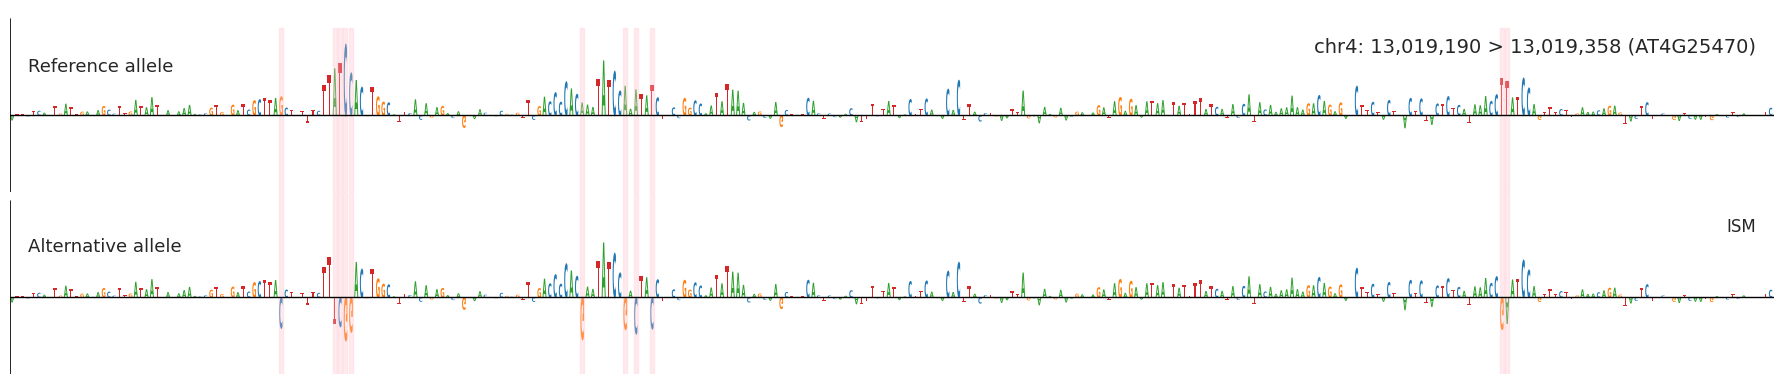

In [125]:
#results_df = pd.read_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_new.csv")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]

#loss_df = loss_df.loc[(loss_df.relative_position<1500)&(loss_df.relative_position>900)]

plot_ref_alt_ism(
    gene=gene,
    chrom='chr4',
    sum_lfc=general_sum_lfc-general_sum_lfc.mean(0),
    ref_sequence=ref_allele,
    results_df=loss_df,
    window_padding=50
)

# Mutations for cold

In [126]:
gex_metadata.iloc[282]

Sample                 SRX1881753
SampleName           Cold 3 hours
Tissue                     leaves
Ecotype                     Col-0
Genotype                       --
Treatment                    cold
Project               PRJNA324514
TotalReads               27297258
UniqueMappedRatio          0.9087
ReleaseDate             2016/8/26
Name: 282, dtype: object

In [ ]:
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=sum_lfc[:,:,282],
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df_full,
    motif_dict=pssm_dict_jaspar,
    metadata=metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=0.5,
    score_threshold=0.8,
    pad=15
)
#results_df.to_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}.csv",index=False)
results_df.head()

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
0,AT4G25470,Chr4,1149,13016336,-1,C,A,bHLH74,Loss,False
1,AT4G25470,Chr4,1149,13016336,-1,C,A,NID1,Loss,No bed file found
2,AT4G25470,Chr4,1149,13016336,-1,C,A,DOF5.3,Gain,No bed file found
3,AT4G25470,Chr4,1149,13016336,-1,C,A,BZIP28,Loss,No bed file found
4,AT4G25470,Chr4,1149,13016336,-1,C,A,MYC3,Loss,False


In [131]:
results_df.chip_peak_overlap.value_counts()

chip_peak_overlap
No bed file found    191
False                 81
True                  78
Name: count, dtype: int64

In [128]:
results_df.loc[results_df.chip_peak_overlap==True]

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
5,AT4G25470,Chr4,1149,13016336,-1,C,A,AT5G04760,Loss,True
7,AT4G25470,Chr4,1149,13016336,-1,C,A,PIF1,Loss,True
10,AT4G25470,Chr4,1149,13016336,-1,C,A,ABF4,Loss,True
12,AT4G25470,Chr4,1149,13016336,-1,C,A,PIF3,Loss,True
15,AT4G25470,Chr4,1149,13016336,-1,C,A,BIM2,Loss,True
...,...,...,...,...,...,...,...,...,...,...
312,AT4G25470,Chr4,1363,13016122,-1,T,G,AT5G61620,Loss,True
318,AT4G25470,Chr4,1146,13016339,-1,A,T,AT5G04760,Loss,True
328,AT4G25470,Chr4,1148,13016337,-1,C,T,AT5G04760,Loss,True
342,AT4G25470,Chr4,1204,13016281,-1,A,T,RVE1,Loss,True


In [132]:
results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
].motif.unique()

array(['AT5G04760', 'PIF1', 'ABF4', 'PIF3', 'BIM2', 'GBF2', 'PIF4',
       'ABF1', 'PIF5', 'ABI5', 'TREE1', 'ABF3', 'RVE1', 'LHY', 'GBF3',
       'NFYC2', 'CCA1', 'AT1G74840', 'AT5G56840', 'AT1G19000',
       'AT5G61620'], dtype=object)

1136 ['C']
1145 ['G']
1146 ['T']
1147 ['C']
1148 ['G', 'T']
1149 ['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1150 ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
1151 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1153 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1192 ['G']
1200 ['G', 'G']
1202 ['C', 'C', 'G', 'G']
1204 ['T', 'T']
1205 ['C', 'C']
1363 ['G', 'G', 'G', 'G', 'G']


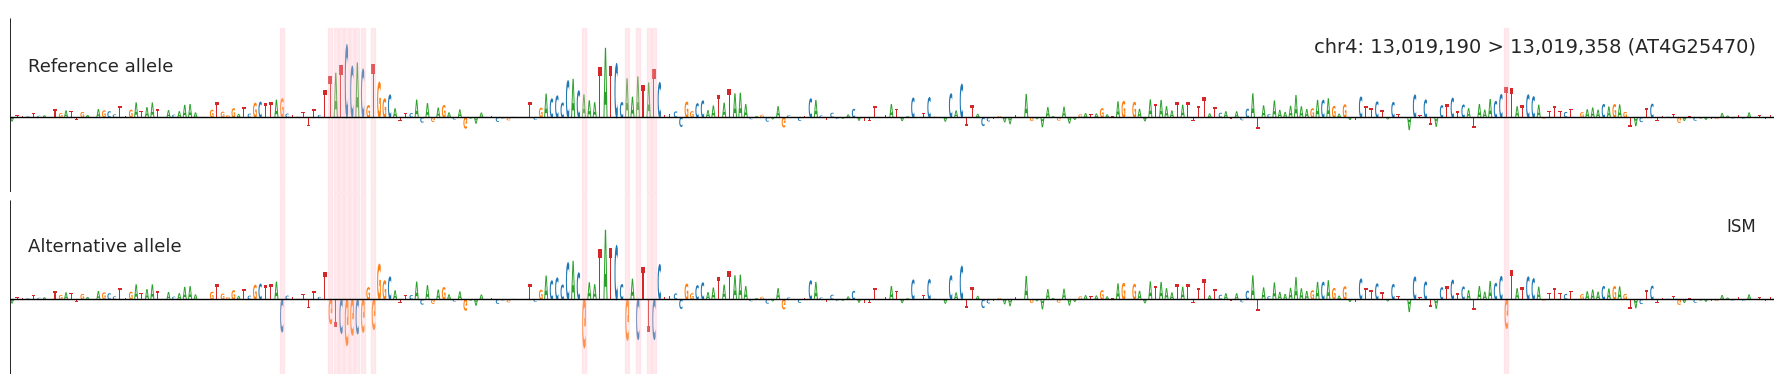

In [130]:
#results_df = pd.read_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_new.csv")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]

#loss_df = loss_df.loc[(loss_df.relative_position<1500)&(loss_df.relative_position>900)]

plot_ref_alt_ism(
    gene=gene,
    chrom='chr4',
    sum_lfc=sum_lfc[:,:,282]-sum_lfc[:,:,282].mean(0),
    ref_sequence=ref_allele,
    results_df=loss_df,
    window_padding=50
)